# Hypothesis 1:
We can use the **study time**, **grade 1** and **grade 2** to determine if the student will have good **final grade**

## Notes:

Why we use **Grade 1** and **Grade 2**: <br>
By including **grade 1** and **grade 2**, we are testing how much "momentum" matters: 

Example 1:
Does a student's performance for **grade 1** matter more than their **study habits** <br>

Example 2:
Usually, **grade 2** is the strongest predictor of the **final grade**, is it possible **study time** can still "move the needle" even if a student had a bad start in **grade 1**. <br>

## Setup:

In [145]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [146]:
# We use this to map string enum values with integers
class EnumMapper:
    def __init__(self, values):
        # Get unique values and sort them so the mapping is deterministic
        unique_enums = sorted(list(set(values)))
        # Create bidirectional mappings
        self.string_to_index = {string_value: index for index, string_value in enumerate(unique_enums)}
        self.index_to_string = {index: string_value for index, string_value in enumerate(unique_enums)}

    def transform_column(self, series: pd.Series) -> pd.Series:
        # Transforms a pandas Series of string enums into integers
        return series.map(self.string_to_index)

    def untransform_column(self, series: pd.Series) -> pd.Series:
        # Transforms a pandas Series of integers back into string enums
        return series.map(self.index_to_string)

    def transform_value(self, value: str) -> int:
        # Transforms a single string enum into its integer representation
        if value not in self.string_to_index:
            raise ValueError(f"String enum '{value}' not recognized by the mapper")
        return self.string_to_index[value]

    def untransform_value(self, value: int) -> str:
        # Transforms a single integer back into its string enum representation
        if value not in self.index_to_string:
            raise ValueError(f"Integer '{value}' not recognized by the mapper")
        return self.index_to_string[value]
    
    def values_info(self) -> dict:
        # Displays the current string-to-integer mappings and returns the mapping dictionary.
        print("Enum Mapping Information:")
        if not self.string_to_index:
            print("No mappings found.")
        else:
            for string_value, index in self.string_to_index.items():
                print(f"Integer: {index}  <-->  String: '{string_value}'")

    def mapping(self) :
        # Returns the mapping object
        return self.index_to_string
    
    def count(self) -> int:
        # Returns the mapping value count
        return len(self.index_to_string)

## Training Data:

In [147]:
training_data = pd.read_csv('../../data/train.csv',  usecols=['student_id', 'grade_1', 'grade_2', 'final_grade', 'study_time'])
training_data

,student_id,study_time,grade_1,grade_2,final_grade
0,1,2 to 5 hours,5,6,6
1,2,2 to 5 hours,5,5,6
2,3,2 to 5 hours,7,8,10
3,4,5 to 10 hours,15,14,15
4,5,2 to 5 hours,6,10,10
...,...,...,...,...,...
390,391,2 to 5 hours,9,9,9
391,392,<2 hours,14,16,16
392,393,<2 hours,10,8,7
393,394,<2 hours,11,12,10


In [148]:
study_time_mapper = EnumMapper(training_data['study_time'])
study_time_mapper.values_info()

Enum Mapping Information:
Integer: 0  <-->  String: '2 to 5 hours'
Integer: 1  <-->  String: '5 to 10 hours'
Integer: 2  <-->  String: '<2 hours'
Integer: 3  <-->  String: '>10 hours'


In [149]:
training_data['study_time'] = study_time_mapper.transform_column(training_data['study_time'])
training_data

,student_id,study_time,grade_1,grade_2,final_grade
0,1,0,5,6,6
1,2,0,5,5,6
2,3,0,7,8,10
3,4,1,15,14,15
4,5,0,6,10,10
...,...,...,...,...,...
390,391,0,9,9,9
391,392,2,14,16,16
392,393,2,10,8,7
393,394,2,11,12,10


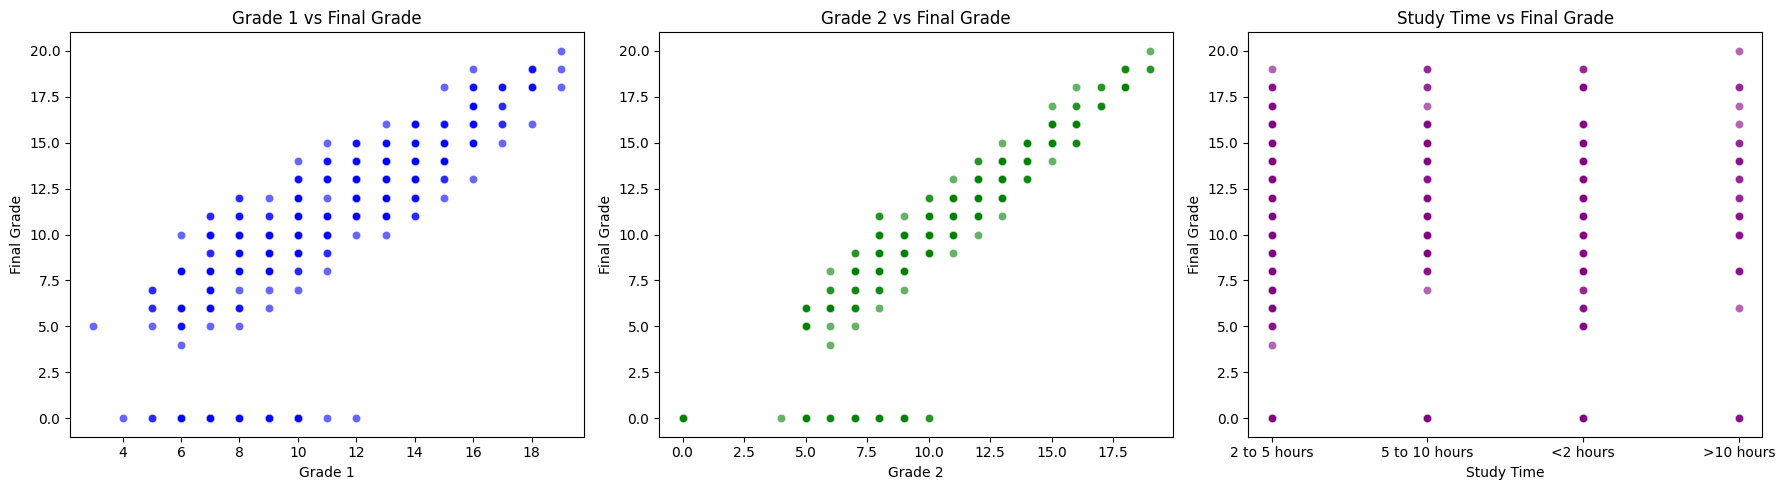

In [150]:
# Create a figure with subplots for our scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Diagram 1: Grade 1 vs Final Grade
axes[0].set_title('Grade 1 vs Final Grade')
axes[0].set_xlabel("Grade 1")
axes[0].set_ylabel("Final Grade")
sns.scatterplot(data=training_data, x='grade_1', y='final_grade', ax=axes[0], color='blue', alpha=0.6)

# Diagram 2: Grade 2 vs Final Grade
axes[1].set_title('Grade 2 vs Final Grade')
axes[1].set_xlabel("Grade 2")
axes[1].set_ylabel("Final Grade")
sns.scatterplot(data=training_data, x='grade_2', y='final_grade', ax=axes[1], color='green', alpha=0.6)

# Diagram 3: Study Time vs Final Grade
axes[2].set_title('Study Time vs Final Grade')
axes[2].set_xlabel("Study Time")
axes[2].set_ylabel("Final Grade")
axes[2].set_xticks(list(study_time_mapper.mapping().keys()))
axes[2].set_xticklabels(list(study_time_mapper.mapping().values()))
sns.scatterplot(data=training_data, x='study_time', y='final_grade', ax=axes[2], color='purple', alpha=0.6)

plt.tight_layout()
plt.show()

In [151]:
# Define our features (X) and target (Y)
X = training_data[['grade_1', 'grade_2', 'study_time']]
Y = training_data['final_grade']

# Split the data: 80% for training, 20% for testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, Y_train)

# Save coefficients in separate variables
intercept = model.intercept_
grade_1_coef, grade_2_coef, study_time_coef = model.coef_

# Make predictions on the test set
Y_pred = model.predict(X_test)

# Calculate Mean Squared Error and R-squared score
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)


# Display the learned coefficients
print("Model Coefficients:")
print(f"Grade 1: {grade_1_coef}")
print(f"Grade 2:  {grade_2_coef}")
print(f"Study Time: {study_time_coef}")
print("\n")
print("Model Intercept:", intercept)
print("\n")
print(f"Mean Squared Error: {mse}")
print("\n")
print(f"R-squared Score: {r2}")
print("\n")
print("Interpretation:")
print(f"The model explains {r2*100:.1f}% of the variance in the final grade.")

Model Coefficients:
Grade 1: 0.16272402382902668
Grade 2:  0.9931099840950941
Study Time: 0.024977962269090704


Model Intercept: -2.0539983992191697


Mean Squared Error: 4.229348051527949


R-squared Score: 0.7937411215767048


Interpretation:
The model explains 79.4% of the variance in the final grade.


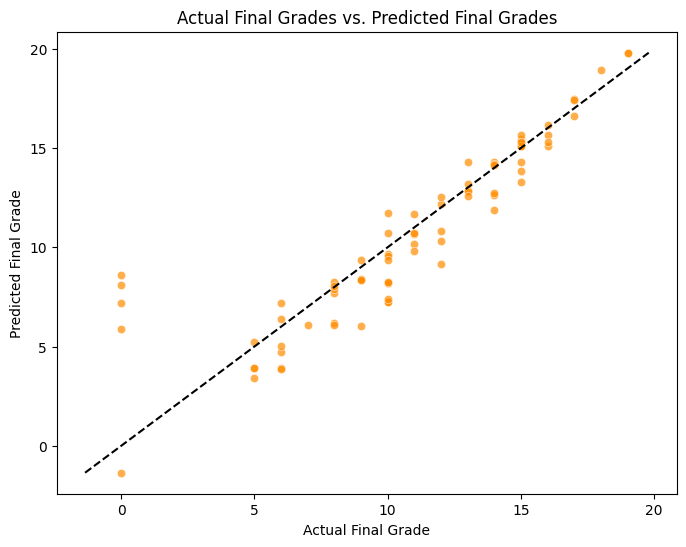

In [152]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test, y=Y_pred, color='darkorange', alpha=0.7)

# Add a diagonal line representing perfect predictions
max_val = max(Y_test.max(), Y_pred.max())
min_val = min(Y_test.min(), Y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')

plt.xlabel('Actual Final Grade')
plt.ylabel('Predicted Final Grade')
plt.title('Actual Final Grades vs. Predicted Final Grades')
plt.show()

In [153]:
# def predict_final_grade(grade_1, grade_2, study_time):
#     return ((grade_1_coef * grade_1) + (grade_2_coef * grade_2) + (study_time_coef * study_time) + intercept)

def predict_final_grade(grade_1, grade_2, study_time):
    
    X = pd.DataFrame({
        'grade_1': grade_1,
        'grade_2': grade_2,
        'study_time': study_time
    })
    
    return model.predict(X)

In [154]:
grade_1_mean = training_data['grade_1'].mean()
grade_2_mean = training_data['grade_2'].mean()
study_time_mean = training_data['study_time'].mean()

grade_1_data = np.linspace(training_data['grade_1'].min(), training_data['grade_1'].max(), 100)
grade_2_data = np.linspace(training_data['grade_2'].min(), training_data['grade_2'].max(), 100)
study_time_data = np.linspace(training_data['study_time'].min(), training_data['study_time'].max(), 100)

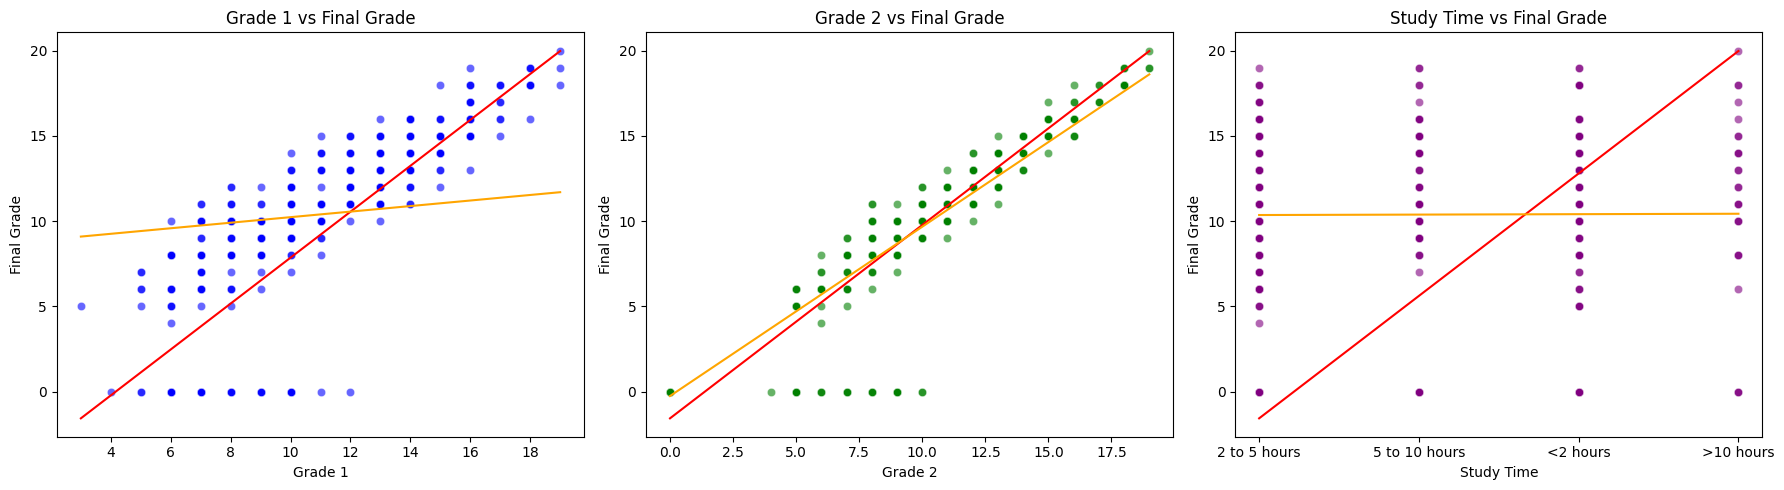

In [155]:
# Create a figure with subplots for our scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Diagram 1: Grade 1 vs Final Grade
axes[0].set_title('Grade 1 vs Final Grade')
axes[0].set_xlabel("Grade 1")
axes[0].set_ylabel("Final Grade")
sns.scatterplot(data=training_data, x='grade_1', y='final_grade', ax=axes[0], color='blue', alpha=0.6)
sns.lineplot(x=grade_1_data, y=predict_final_grade(grade_1_data, grade_2_data, study_time_data), ax=axes[0], color='red')
sns.lineplot(x=grade_1_data, y=predict_final_grade(grade_1_data, grade_2_mean, study_time_mean), ax=axes[0], color='orange')

# Diagram 2: Grade 2 vs Final Grade
axes[1].set_title('Grade 2 vs Final Grade')
axes[1].set_xlabel("Grade 2")
axes[1].set_ylabel("Final Grade")
sns.scatterplot(data=training_data, x='grade_2', y='final_grade', ax=axes[1], color='green', alpha=0.6)
sns.lineplot(x=grade_2_data, y=predict_final_grade(grade_1_data, grade_2_data, study_time_data), ax=axes[1], color='red')
sns.lineplot(x=grade_2_data, y=predict_final_grade(grade_1_mean, grade_2_data, study_time_mean), ax=axes[1], color='orange')

# Diagram 3: Study Time vs Final Grade
axes[2].set_title('Study Time vs Final Grade')
axes[2].set_xlabel("Study Time")
axes[2].set_ylabel("Final Grade")
axes[2].set_xticks(list(study_time_mapper.mapping().keys()))
axes[2].set_xticklabels(list(study_time_mapper.mapping().values()))
sns.scatterplot(data=training_data, x='study_time', y='final_grade', ax=axes[2], color='purple', alpha=0.6)
sns.lineplot(x=study_time_data, y=predict_final_grade(grade_1_data, grade_2_data, study_time_data), ax=axes[2], color='red')
sns.lineplot(x=study_time_data, y=predict_final_grade(grade_1_mean, grade_2_mean, study_time_data), ax=axes[2], color='orange')

plt.tight_layout()
plt.show()
